In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import cv2
from skimage import filters
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, disk
from skimage.segmentation import find_boundaries
from skimage.filters.rank import entropy
from skimage.filters import threshold_multiotsu
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

# Color Deconvolution

In [ ]:
# color deconvolution
def deconvolve_her2_cen17(image):
    def rgb_to_od(img):
        img = img.astype(np.float32) + 1
        return -np.log10(img / 255.0)

    stain_matrix = np.array([
        [0.533, 0.653, 0.538],  # HER2 (black)
        [0.273, 0.892, 0.360],  # CEN17 (pink)
        [0.0,   0.0,   0.0   ]  
    ])

    stain_matrix[2, :] = np.cross(stain_matrix[0, :], stain_matrix[1, :])
    
    stain_matrix /= np.linalg.norm(stain_matrix, axis=1)[:,np.newaxis]

    od = rgb_to_od(image)
    
    concentrations = np.dot(od.reshape(-1, 3), np.linalg.inv(stain_matrix))
    conc_img = concentrations.reshape(image.shape)

    her2_norm = conc_img[:, :, 0]
    cen17_norm = conc_img[:, :, 1]

    return conc_img[:, :, 0], conc_img[:, :, 1] # HER2, CEN17

# CEN17 Signal Detection

In [ ]:
def detect_cen17(cen17_channel, image, visualize=False):
    norm = cv2.normalize(cen17_channel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # remove noise
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    hue, sat, val = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    remove_mask = ((hue >= 25) & (hue <= 130)) | (val < 50) | (sat < 120)
    mask[remove_mask] = 0

    labeled_mask = label(mask)
    cleaned_labeled_mask = remove_small_objects(labeled_mask, min_size=10)

    cleaned_mask = np.zeros_like(mask, dtype=np.uint8)
    for region in regionprops(cleaned_labeled_mask):
        if region.solidity > 0.5:
            for (row, col) in region.coords:
                cleaned_mask[row, col] = 255
                
    image_copy = image.copy()
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(image_copy, contours, -1, (0, 255, 0), 2)
    if visualize:
        plt.figure(figsize=(20, 12))
        plt.subplot(121), plt.imshow(image), plt.title('Original Image'); plt.axis('off')
        plt.subplot(122), plt.imshow(image_copy), plt.title('CEN17 Detection'); plt.axis('off')
        plt.tight_layout()
        plt.show()

    return cleaned_mask, image_copy

# HER2 Signal Detection

In [ ]:
def detect_her2(her2_channel, cen17_mask, image, visualize=False):
    norm = cv2.normalize(her2_channel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    mean_val = np.mean(norm)
    foreground_ratio = (norm > filters.threshold_otsu(norm)).sum() / norm.size
    laplacian_var = cv2.Laplacian(norm, cv2.CV_64F).var()
    hist_kurtosis = kurtosis(np.histogram(norm, bins=256)[0])
    entropy_val = entropy(norm, disk(5)).mean()
    sd = np.std(norm)

    # mutli-Otsu thresholding 
    thresholds = threshold_multiotsu(norm, classes=5)
    if foreground_ratio < 0.02:
        threshold_used = thresholds[1]
    elif (mean_val < 75) or ((mean_val < 85) and (sd < 6) and (entropy_val < 2)):
        threshold_used = thresholds[2]
    else:
        threshold_used = thresholds[3]

    mask = (norm > threshold_used).astype(np.uint8) * 255

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    blue_mask = None

    # remove noise
    if entropy_val > 2.5 and foreground_ratio > 0.4:
        blue_mask = ((h >= 85) & (h <= 120)) & (v >= 150)
        
    elif sd < 5 and foreground_ratio > 0.2:
        blue_mask = ((h >= 85) & (h <= 125)) | (v >= 140)
        
    elif (entropy_val < 2.5 and foreground_ratio > 0.3) or (mean_val > 120 and foreground_ratio > 0.25):
        blue_mask = ((h >= 85) & (h <= 135)) & (v >= 135)
        
    elif entropy_val > 2 and foreground_ratio < 0.05:
        blue_mask = None
        
    elif mean_val > 90 and laplacian_var < 10 and foreground_ratio < 0.15:
        blue_mask = ((h >= 85) & (h <= 135)) & (v >= 160)
        
    else:
        blue_mask = (h >= 85) & (h <= 135)
        

    if blue_mask is not None:
        mask[blue_mask] = 0

    her2_labels = label(mask)
    cen17_labels = label(cen17_mask)
    cleaned_mask = np.zeros_like(mask, dtype=np.uint8)

    # remove small region and those overalapped with CEN17 mask 
    for region in regionprops(her2_labels):
        if region.area > 5:
            coords = tuple(zip(*region.coords))
            if foreground_ratio > 0.05:
                overlap_pixels = sum(cen17_labels[r, c] != 0 for r, c in region.coords)
                overlap_ratio = overlap_pixels / region.area
                if overlap_ratio <= 0.2:
                    cleaned_mask[coords] = 255
            else:
                cleaned_mask[coords] = 255

    image_copy = image.copy()
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(image_copy, contours, -1, (0, 255, 0), 2)

    if visualize:
        plt.figure(figsize=(20, 12))
        plt.subplot(121), plt.imshow(image), plt.title('Original Image'); plt.axis('off')
        plt.subplot(122), plt.imshow(image_copy), plt.title('HER2 Detection'); plt.axis('off')
        plt.tight_layout()
        plt.show()

    return cleaned_mask, image_copy

In [ ]:
def load_and_preprocess(image_path, mask_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    nuclei_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return img, nuclei_mask

# HER2 Cluster Handling

In [ ]:
# get the maximun reference single HER2 signal size for handling HER2 cluster

def extract_signal_areas(mask, min_area=5):
    labeled = label(mask)
    return [r.area for r in regionprops(labeled) if r.area >= min_area]

def get_max_her2_area_threshold(image_dir, target_ids, percentile=95, visualize=False):
    all_areas = []

    for img_id in target_ids:
        test_filename = f"{img_id}.png"
        img_path_candidates = glob.glob(f"{image_dir}/{test_filename}")
        if not img_path_candidates:
            print(f"Image {img_id} not found.")
            continue
        img_path = img_path_candidates[0]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        her2_channel, cen17_channel = deconvolve_her2_cen17(img)
        cen17_mask, _ = detect_cen17(cen17_channel, img)
        her2_mask, _ = detect_her2(her2_channel, cen17_mask, img)

        areas = extract_signal_areas(her2_mask)
        all_areas.extend(areas)

    if not all_areas:
        raise ValueError("No valid HER2 signals found.")

    all_areas = np.array(all_areas)
    threshold_value = np.percentile(all_areas, percentile)

    if visualize:
        plt.figure(figsize=(10, 6))
        plt.hist(all_areas, bins=40, color='black', alpha=0.8)
        plt.axvline(threshold_value, color='red', linestyle='--', label=f'{percentile}th percentile = {threshold_value:.1f}')
        plt.title("HER2 Signal Area Distribution")
        plt.xlabel("Area (pixels)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    print(f"Maximun Individual HER2 Signal Area = {threshold_value:.1f}")

    return threshold_value

In [ ]:
def split_clusters(mask, reference_size, area_threshold, image=None):
    labeled = label(mask)
    props = regionprops(labeled)

    cluster_props = []
    cluster_contours = []
    cluster_mask = np.zeros(mask.shape, dtype=np.uint8)
    
    her2_vis = image.copy() if image is not None else None

    for region in props:
        region_mask = (labeled == region.label).astype(np.uint8)
        contours, _ = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = contours[0]

        if region.area > area_threshold:
            # Cluster signal
            cluster_area = region.area
            estimated_count = max(1, int(round(cluster_area / reference_size)))
            cluster_props.append({
                "cx": int(region.centroid[1]),
                "cy": int(region.centroid[0]),
                "area": cluster_area,
                "count": estimated_count
            })
            cluster_contours.append(contour)
            cv2.drawContours(cluster_mask, [contour], -1, 255, -1)
            if her2_vis is not None:
                cv2.drawContours(her2_vis, [contour], -1, (0, 255, 0), 2) 
                cv2.putText(her2_vis, str(estimated_count),
                            (int(region.centroid[1]), int(region.centroid[0])),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        else:
            # Non-cluster (individual HER2 signal)
            if her2_vis is not None:
                cv2.drawContours(her2_vis, [contour], -1, (0, 255, 0), 2)  

    return cluster_props, cluster_contours, cluster_mask, her2_vis

In [ ]:
def count_signals_per_nucleus(img, her2_mask, cen17_mask, nuclei_mask, MAX_INDIVIDUAL_HER2_AREA):
    cluster_props, cluster_contours, _, her2_vis_with_labels = split_clusters(
        her2_mask, MAX_INDIVIDUAL_HER2_AREA, MAX_INDIVIDUAL_HER2_AREA, image=img
    )
    
    nucleus_labels = label(nuclei_mask)
    pink_labels = label(cen17_mask)
    pink_regions = regionprops(pink_labels)
    black_labels = label(her2_mask)
    black_regions = regionprops(black_labels)
    single_black_regions = [r for r in black_regions if r.area <= MAX_INDIVIDUAL_HER2_AREA]

    cluster_mask_global = np.zeros_like(nucleus_labels, dtype=np.uint8)
    for cnt in cluster_contours:
        cv2.drawContours(cluster_mask_global, [cnt], -1, 1, -1)

    filtered_single_black_regions = [
        r for r in single_black_regions
        if cluster_mask_global[int(r.centroid[0]), int(r.centroid[1])] == 0
    ]

    filtered_nucleus_ids = [
        region.label for region in regionprops(nucleus_labels)
        if region.solidity >= 0.9
    ]

    results = []
    for nucleus_id in filtered_nucleus_ids:
        nucleus_mask_bin = (nucleus_labels == nucleus_id).astype(np.uint8)
        cen17_count = sum(1 for r in pink_regions if nucleus_mask_bin[int(r.centroid[0]), int(r.centroid[1])])
        her2_count = sum(1 for r in filtered_single_black_regions if nucleus_mask_bin[int(r.centroid[0]), int(r.centroid[1])])
        results.append({
            "nucleus_id": nucleus_id,
            "her2_count": her2_count,
            "cen17_count": cen17_count
        })

    df = pd.DataFrame(results)
    df['differentiation'] = df['her2_count'] - df['cen17_count']

    return df, filtered_single_black_regions, cluster_props, cluster_contours, nucleus_labels, pink_labels, black_labels, pink_regions, her2_vis_with_labels

In [ ]:
def update_her2_with_clusters(df, cluster_props, cluster_contours, nucleus_labels):
    for cluster, cnt in zip(cluster_props, cluster_contours):
        cluster_mask = np.zeros_like(nucleus_labels, dtype=np.uint8)
        cv2.drawContours(cluster_mask, [cnt], -1, 1, -1)
        overlapping_nuclei = np.unique(nucleus_labels[(cluster_mask == 1) & (nucleus_labels > 0)])
        for nid in overlapping_nuclei:
            df.loc[df['nucleus_id'] == nid, 'her2_count'] += cluster['count']
    df['differentiation'] = df['her2_count'] - df['cen17_count']
    return df

# Computation of HER2/CEN17 ratio

In [ ]:
def compute_ratios_and_status(df, image_id, df_ratio):
    results_summary = []

    expert_ratio = df_ratio[df_ratio['image_id'] == image_id]['ratio'].values[0]
    expert_status = 'Amplified' if expert_ratio >= 2.0 else 'Non-Amplified'
    results_summary.append({
        "image_id": image_id, 
        "Method": "Expert", 
        "Total_Nuclei": pd.NA,
        "HER2": pd.NA, 
        "CEN17": pd.NA, 
        "Ratio": expert_ratio, 
        "Status": expert_status
    })

    all_nuclei = df[(df['her2_count'] >= 1) & (df['cen17_count'] >= 1)]
    her2_all = all_nuclei['her2_count'].sum()
    cen17_all = all_nuclei['cen17_count'].sum()
    ratio_all = round(her2_all / cen17_all, 2)
    status_all = 'Amplified' if ratio_all >= 2.0 else 'Non-Amplified'
    results_summary.append({
        "image_id": image_id, 
        "Method": "All Nuclei",
        "Total_Nuclei": len(all_nuclei), 
        "HER2": her2_all,
        "CEN17": cen17_all, 
        "Ratio": ratio_all, 
        "Status": status_all
    })

    count_2_2 = len(df[(df['her2_count'] >= 2) & (df['cen17_count'] >= 2)])
    count_2_1 = len(df[(df['her2_count'] >= 2) & (df['cen17_count'] >= 1)])
    count_1_1 = len(df[(df['her2_count'] >= 1) & (df['cen17_count'] >= 1)])

    if count_2_2 >= 20:
        filtered = df[(df['her2_count'] >= 2) & (df['cen17_count'] >= 2)]
        method_used = "Meet Criteria (2 HER2:2 CEN17)"
    elif count_2_1 >= 20:
        filtered = df[(df['her2_count'] >= 2) & (df['cen17_count'] >= 1)]
        method_used = "Meet Criteria (2 HER2:1 CEN17)"
    else:
        filtered = df[(df['her2_count'] >= 1) & (df['cen17_count'] >= 1)]
        method_used = "Meet Criteria (1 HER2:1 CEN17)"

    filtered = filtered.sort_values(by='differentiation', ascending=False)
    
    her2_filter, cen17_filter = filtered['her2_count'].sum(), filtered['cen17_count'].sum()
    ratio_filter = round(her2_filter / cen17_filter, 2) if cen17_filter else np.nan
    status_filter = 'Amplified' if ratio_filter >= 2.0 else 'Non-Amplified'
    
    results_summary.append({
        "image_id": image_id, 
        "Method": method_used,
        "Total_Nuclei": len(filtered), 
        "HER2": her2_filter,
        "CEN17": cen17_filter, 
        "Ratio": ratio_filter, 
        "Status": status_filter
    })

    selected_20 = filtered.head(20)
    ratio_20 = round(selected_20['her2_count'].sum() / selected_20['cen17_count'].sum(), 2) if selected_20['cen17_count'].sum() else np.nan
    if 1.8 <= ratio_20 <= 2.2 and len(filtered) >= 40:
        combined = pd.concat([selected_20, filtered.iloc[20:40]])
        method_20 = "20+20 Method (Extended to 40)"
    else:
        combined = selected_20
        method_20 = "20+20 Method (Top 20)"

    her2_20 = combined['her2_count'].sum()
    cen17_20 = combined['cen17_count'].sum()
    ratio_20_final = round(her2_20 / cen17_20, 2) if cen17_20 else np.nan
    status_20 = 'Amplified' if ratio_20_final >= 2.0 else 'Non-Amplified'
    results_summary.append({
        "image_id": image_id, 
        "Method": method_20,
        "Total_Nuclei": len(combined), 
        "HER2": her2_20,
        "CEN17": cen17_20, 
        "Ratio": ratio_20_final, 
        "Status": status_20
    })

    return results_summary, combined 

In [ ]:
def process_one(image_path, mask_path, image_id, df_ratio, MAX_INDIVIDUAL_HER2_AREA):
    img, nuclei_mask = load_and_preprocess(image_path, mask_path)
    her2_channel, cen17_channel = deconvolve_her2_cen17(img)

    cen17_mask, cen17_vis = detect_cen17(cen17_channel, img)
    her2_mask, her2_vis = detect_her2(her2_channel, cen17_mask, img)

    df, filtered_black, cluster_props, cluster_contours, \
    nucleus_labels, pink_labels, black_labels, pink_regions, her2_vis_labels = count_signals_per_nucleus(
        img, her2_mask, cen17_mask, nuclei_mask, MAX_INDIVIDUAL_HER2_AREA
    )

    df = update_her2_with_clusters(df, cluster_props, cluster_contours, nucleus_labels)
    results_summary, selected_nuclei_df = compute_ratios_and_status(df, image_id, df_ratio)


    # All nuclei 
    selected_nuclei_overlay = img.copy()
    for region in regionprops(label(nuclei_mask)):
        contours, _ = cv2.findContours((label(nuclei_mask) == region.label).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(selected_nuclei_overlay, contours, -1, (255, 0, 0), 2)

    # All nuclei and signals
    contour_overlay = np.ones_like(img) * 255
    for region in regionprops(label(nuclei_mask)):
        contours, _ = cv2.findContours((label(nuclei_mask) == region.label).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(contour_overlay, contours, -1, (0, 255, 0), 2)
    for region in regionprops(label(cen17_mask)):
        contours, _ = cv2.findContours((label(cen17_mask) == region.label).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(contour_overlay, contours, -1, (255, 0, 255), -1)
    for region in regionprops(label(her2_mask)):
        contours, _ = cv2.findContours((label(her2_mask) == region.label).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(contour_overlay, contours, -1, (0, 0, 0), -1)
    for cnt in cluster_contours:
        cv2.drawContours(contour_overlay, [cnt], -1, (0, 0, 0), -1)

    # Quantified nuclei and signals)
    selected_overlay = np.ones_like(img) * 255
    top_method = results_summary[-1]
    selected_ids = selected_nuclei_df['nucleus_id'].tolist()

    for nid in selected_ids:
        nucleus_mask = (nucleus_labels == nid).astype(np.uint8)
        contours, _ = cv2.findContours(nucleus_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(selected_overlay, contours, -1, (0, 255, 0), 2)
    for region in pink_regions:
        if nucleus_labels[int(region.centroid[0]), int(region.centroid[1])] in selected_ids:
            contours, _ = cv2.findContours((pink_labels == region.label).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(selected_overlay, contours, -1, (255, 0, 255), -1)
    for region in filtered_black:
        if nucleus_labels[int(region.centroid[0]), int(region.centroid[1])] in selected_ids:
            contours, _ = cv2.findContours((black_labels == region.label).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(selected_overlay, contours, -1, (0, 0, 0), -1)
    for cluster, cnt in zip(cluster_props, cluster_contours):
        cluster_mask = np.zeros_like(nucleus_labels, dtype=np.uint8)
        cv2.drawContours(cluster_mask, [cnt], -1, 1, -1)
        overlapping = np.unique(nucleus_labels[(cluster_mask == 1) & (nucleus_labels > 0)])
        if any(n in selected_ids for n in overlapping):
            cv2.drawContours(selected_overlay, [cnt], -1, (0, 0, 0), -1)

    
    ## Visualization: signal quantification result
    # plot_figure_3_panel(
    #     image_id=image_id,
    #     original_img=img,
    #     detected_overlay=contour_overlay,
    #     quantified_overlay=selected_overlay,
    #     save_path="/kaggle/working"
    # )
    

    # Visualization: signal detection + quantification result
    plot_figure_6_panel(
        image_id=image_id,
        original_img=img,
        selected_nuclei_overlay=selected_nuclei_overlay,
        her2_vis=her2_vis_labels, # her2_vis,
        cen17_vis=cen17_vis,
        detected_overlay=contour_overlay,
        quantified_overlay=selected_overlay,
        save_path="/kaggle/working"
    )

    return results_summary, contour_overlay, selected_overlay

In [ ]:
def plot_figure_3_panel(image_id, 
                                original_img, 
                                detected_overlay, 
                                quantified_overlay, 
                                save_path="/kaggle/working"):
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 12)) 

    axs[0].imshow(original_img)
    axs[0].set_title(f"(a) Original Image (ID: {image_id})", fontsize = 15)
    axs[0].axis('off')

    axs[1].imshow(detected_overlay)
    axs[1].set_title("(b) Detection Overview", fontsize = 15)
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    for spine in axs[1].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('lightgrey')
        spine.set_linewidth(1)

    axs[2].imshow(quantified_overlay)
    axs[2].set_title("(c) Quantification Results", fontsize = 15)
    axs[2].set_xticks([])
    axs[2].set_yticks([])
    for spine in axs[2].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('lightgrey')
        spine.set_linewidth(1)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05) 
    
    os.makedirs(save_path, exist_ok=True)
    output_file = os.path.join(save_path, f"{image_id}.png")
    plt.savefig(output_file, dpi=200, bbox_inches='tight')
    plt.close()
    
    print(f"Saved visualization to {output_file}")

In [ ]:
def plot_figure_6_panel(image_id, 
                                original_img, selected_nuclei_overlay, 
                                her2_vis, cen17_vis, 
                                detected_overlay, quantified_overlay, 
                                save_path="/kaggle/working"):
    
    fig, axs = plt.subplots(3, 2, figsize=(15, 20)) 

    axs[0, 0].imshow(original_img)
    axs[0, 0].set_title(f"(a) Original Image (ID: {image_id})", fontsize = 15)
    axs[0, 0].axis('off')

    axs[0, 1].imshow(selected_nuclei_overlay)
    axs[0, 1].set_title("(b) Nuclei Detection", fontsize = 15)
    axs[0, 1].axis('off')

    axs[1, 0].imshow(her2_vis)
    axs[1, 0].set_title("(c) HER2 Detection", fontsize = 15)
    axs[1, 0].axis('off')

    axs[1, 1].imshow(cen17_vis)
    axs[1, 1].set_title("(d) CEN17 Detection", fontsize = 15)
    axs[1, 1].axis('off')

    axs[2, 0].imshow(detected_overlay)
    axs[2, 0].set_title("(e) Detection Overview", fontsize = 15)
    axs[2, 0].set_xticks([])
    axs[2, 0].set_yticks([])
    for spine in axs[2, 0].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('lightgrey')
        spine.set_linewidth(1)

    axs[2, 1].imshow(quantified_overlay)
    axs[2, 1].set_title("(f) Quantification Results", fontsize = 15)
    axs[2, 1].set_xticks([])
    axs[2, 1].set_yticks([])
    for spine in axs[2, 1].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('lightgrey')
        spine.set_linewidth(1)

    plt.tight_layout()
    
    os.makedirs(save_path, exist_ok=True)
    output_file = os.path.join(save_path, f"{image_id}.png")
    plt.savefig(output_file, dpi=200, bbox_inches='tight')
    plt.close()
    
    print(f"Saved visualization to {output_file}")

# Testing

In [ ]:
# Define paths
image_dir = "/kaggle/input/subset-50/images"
full_mask_root = "/kaggle/input/subset-50/masks"
df_ratio = pd.read_csv('/kaggle/input/her2cen17-ratio/ratio.csv')

# Reference images for HER2 area threshold estimation
reference_image_dir = image_dir
reference_image_ids = [429493112, 429493059, 169284222, 169284257, 168136732]

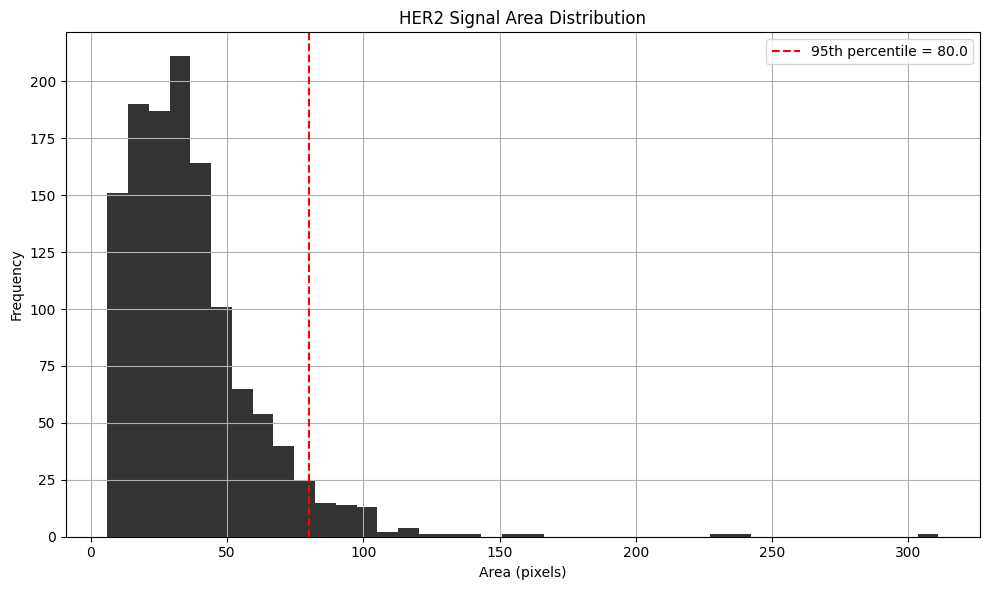

Maximun Individual HER2 Signal Area = 80.0


In [ ]:
MAX_INDIVIDUAL_HER2_AREA = get_max_her2_area_threshold(
    image_dir=reference_image_dir,
    target_ids=reference_image_ids,
    percentile=95,
    visualize=True
)

## 1. Single Image

In [ ]:
# test_filename = "169281946.png" 
# img_path = os.path.join(image_dir, test_filename)
# img_id = int(os.path.splitext(test_filename)[0])
# mask_path = os.path.join(full_mask_root, test_filename)

# methods = []
# if os.path.exists(mask_path):
#     rows, _, _ = process_one(img_path, mask_path, img_id, df_ratio, MAX_INDIVIDUAL_HER2_AREA)
#     methods.extend(rows)
# else:
#     print(f"Mask not found for image {img_id}")

# results_df = pd.DataFrame(methods)
# display(results_df)

## 2. All 50 Images

In [ ]:
methods = []
selected_images = sorted(glob.glob(f"{image_dir}/*.png"))

for img_path in tqdm(selected_images, desc="Processing"):
    img_filename = os.path.basename(img_path)
    img_id = int(os.path.splitext(img_filename)[0])
    mask_path = os.path.join(full_mask_root, img_filename)

    if not os.path.exists(mask_path):
        print(f"Mask missing for {img_id}")
        continue

    try:
        rows, _, _ = process_one(img_path, mask_path, img_id, df_ratio, MAX_INDIVIDUAL_HER2_AREA)
        methods.extend(rows)
    except Exception as e:
        print(f"Error processing {img_id}: {e}")
        continue

results_df = pd.DataFrame(methods)
display(results_df)


Processing:   2%|▏         | 1/50 [01:57<1:36:09, 117.74s/it]

Saved visualization to /kaggle/working/168136732.png


Processing:   4%|▍         | 2/50 [03:59<1:35:53, 119.87s/it]

Saved visualization to /kaggle/working/168136787.png


Processing:   6%|▌         | 3/50 [04:10<55:09, 70.41s/it]   

...

Processing:  98%|█████████▊| 49/50 [2:11:48<02:55, 175.22s/it]

Saved visualization to /kaggle/working/431717817.png


Processing: 100%|██████████| 50/50 [2:12:41<00:00, 159.24s/it]

Saved visualization to /kaggle/working/431717848.png


,image_id,Method,Total_Nuclei,HER2,CEN17,Ratio,Status
0,168136732,Expert,<NA>,<NA>,<NA>,1.70,Non-Amplified
1,168136732,All Nuclei,104,239,206,1.16,Non-Amplified
2,168136732,Meet Criteria (2 HER2:2 CEN17),47,152,125,1.22,Non-Amplified
3,168136732,20+20 Method (Top 20),20,78,48,1.62,Non-Amplified
4,168136787,Expert,<NA>,<NA>,<NA>,1.70,Non-Amplified
...,...,...,...,...,...,...,...
195,431717817,20+20 Method (Top 20),20,34,26,1.31,Non-Amplified
196,431717848,Expert,<NA>,<NA>,<NA>,0.60,Non-Amplified
197,431717848,All Nuclei,36,47,93,0.51,Non-Amplified
198,431717848,Meet Criteria (1 HER2:1 CEN17),36,47,93,0.51,Non-Amplified


In [18]:
results_df.to_csv("/kaggle/working/ratio_condition.csv", index=False)

# Evaluation

## 1. Amplification Status Result

In [20]:
import re

def extract_criteria(method_str):
    match = re.search(r"Meet Criteria \((\d+)\s+HER2\s*:\s*(\d+)\s+CEN17\)", method_str)
    if match:
        her2 = match.group(1)
        cen17 = match.group(2)
        return f"≥{her2}HER2, ≥{cen17}CEN17"
    return None
method_df = results_df[results_df["Method"].str.startswith("20+20 Method")][[
    "image_id", "Total_Nuclei", "HER2", "CEN17", "Ratio", "Status"
]].copy()

criteria_mapping = results_df[results_df["Method"].str.startswith("Meet Criteria")].copy()
criteria_mapping["Applied_Criteria"] = criteria_mapping["Method"].apply(extract_criteria)
criteria_mapping = criteria_mapping[["image_id", "Applied_Criteria"]]

method_df = pd.merge(method_df, criteria_mapping, on="image_id", how="left")

method_df = method_df.rename(columns={
    "Total_Nuclei": "Method_Total_Nuclei",
    "HER2": "Method_HER2_Signal",
    "CEN17": "Method_CEN17_Signal",
    "Ratio": "Method_Ratio",
    "Status": "Method_Status"
})

expert_df = results_df[results_df["Method"] == "Expert"][[
    "image_id", "Ratio", "Status"
]].rename(columns={
    "Ratio": "Expert_Ratio",
    "Status": "Expert_Status"
})

merged_df = pd.merge(method_df, expert_df, on="image_id", how="inner")

ordered_cols = [
    "image_id", "Applied_Criteria", "Method_Total_Nuclei",
    "Method_HER2_Signal", "Method_CEN17_Signal", "Method_Ratio",
    "Method_Status", "Expert_Ratio", "Expert_Status"
]

final_df = merged_df[ordered_cols]

criteria_order = ["≥2HER2, ≥2CEN17", "≥2HER2, ≥1CEN17", "≥1HER2, ≥1CEN17"]
final_df["Applied_Criteria"] = pd.Categorical(final_df["Applied_Criteria"], categories=criteria_order, ordered=True)
final_df_sorted = final_df.sort_values(by=["Applied_Criteria", "image_id"])
final_df_sorted

,image_id,Applied_Criteria,Method_Total_Nuclei,Method_HER2_Signal,Method_CEN17_Signal,Method_Ratio,Method_Status,Expert_Ratio,Expert_Status
0,168136732,"≥2HER2, ≥2CEN17",20,78,48,1.62,Non-Amplified,1.7,Non-Amplified
1,168136787,"≥2HER2, ≥2CEN17",20,76,48,1.58,Non-Amplified,1.7,Non-Amplified
5,168138679,"≥2HER2, ≥2CEN17",20,52,44,1.18,Non-Amplified,1.2,Non-Amplified
7,168138775,"≥2HER2, ≥2CEN17",20,49,41,1.20,Non-Amplified,1.2,Non-Amplified
8,168139685,"≥2HER2, ≥2CEN17",20,278,49,5.67,Amplified,11.0,Amplified
9,169262763,"≥2HER2, ≥2CEN17",20,167,64,2.61,Amplified,3.1,Amplified
11,169282035,"≥2HER2, ≥2CEN17",40,138,87,1.59,Non-Amplified,2.7,Amplified
13,169282298,"≥2HER2, ≥2CEN17",20,95,45,2.11,Amplified,2.6,Amplified
14,169282431,"≥2HER2, ≥2CEN17",20,114,48,2.38,Amplified,2.6,Amplified
15,169282562,"≥2HER2, ≥2CEN17",20,75,47,1.60,Non-Amplified,1.5,Non-Amplified


In [21]:
merged_df.to_csv("/kaggle/working/result.csv", index=False)

## 2. Misclassified Images

In [23]:
merged_df[merged_df["Expert_Status"] != merged_df["Method_Status"]]

,image_id,Method_Total_Nuclei,Method_HER2_Signal,Method_CEN17_Signal,Method_Ratio,Method_Status,Applied_Criteria,Expert_Ratio,Expert_Status
11,169282035,40,138,87,1.59,Non-Amplified,"≥2HER2, ≥2CEN17",2.7,Amplified
20,169283283,20,50,44,1.14,Non-Amplified,"≥2HER2, ≥2CEN17",4.4,Amplified
21,169283307,20,54,30,1.80,Non-Amplified,"≥2HER2, ≥1CEN17",4.4,Amplified
30,169284650,20,71,44,1.61,Non-Amplified,"≥2HER2, ≥2CEN17",2.4,Amplified
34,169285908,20,125,56,2.23,Amplified,"≥2HER2, ≥2CEN17",1.0,Non-Amplified
39,429489055,20,41,22,1.86,Non-Amplified,"≥1HER2, ≥1CEN17",2.8,Amplified


## 3. Classification Evalaution Metrics

Precision: 0.9524
Recall:    0.8000
F1 Score:  0.8696
Accuracy:  0.8800


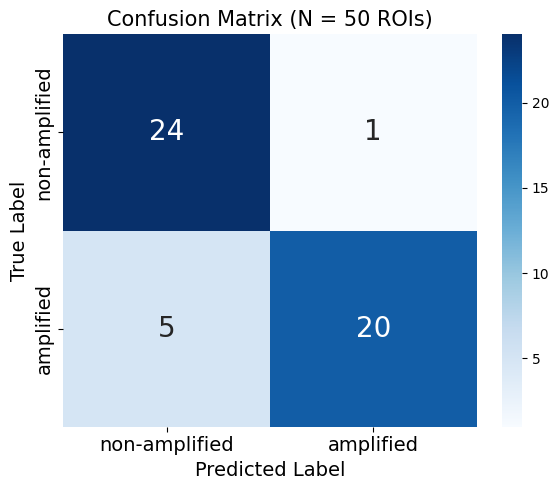

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

df = merged_df

y_true = df['Expert_Status'].map({'Non-Amplified': 0, 'Amplified': 1})
y_pred = df['Method_Status'].map({'Non-Amplified': 0, 'Amplified': 1})

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")



from sklearn.metrics import ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_true, y_pred)

labels = ['non-amplified', 'amplified']

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 20}) 


plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix (N = 50 ROIs)', fontsize=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

## 4. Bland–Altman Plot

In [ ]:
import numpy as np
from scipy.stats import t, ttest_rel

merged = merged_df

manual = merged["Expert_Ratio"]
proposed = merged["Method_Ratio"]

diffs = proposed - manual
means = (proposed + manual) / 2

bias = np.mean(diffs)

sd_diff = np.std(diffs, ddof=1)  
n = len(diffs)

#  95% Confidence Interval for Bias
se = sd_diff / np.sqrt(n)
t_val = t.ppf(0.975, df=n-1)
ci_low = bias - t_val * se
ci_high = bias + t_val * se

# Limits of Agreement (LoA)
loa_low = bias - 1.96 * sd_diff
loa_high = bias + 1.96 * sd_diff

# Paired one-sided t-test
t_stat, p_val_two_sided = ttest_rel(proposed, manual)
p_val_one_sided = p_val_two_sided / 2 

from scipy.stats import pearsonr
corr, p_value = pearsonr(manual, proposed)

print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")
s
print("Bland–Altman Analysis Results")
print(f"Bias: {bias:.2f}")
print(f"95% Confidence Interval: ({ci_low:.2f}, {ci_high:.2f})")
print(f"Limits of Agreement: ({loa_low:.2f}, {loa_high:.2f})")
print(f"One-sided Paired t-test p-value: {p_val_one_sided:.4f}")

Pearson correlation: 0.7469
P-value: 0.0000
Bland–Altman Analysis Results
Bias: -0.06
95% Confidence Interval: (-0.43, 0.31)
Limits of Agreement: (-2.61, 2.48)
One-sided Paired t-test p-value: 0.3638


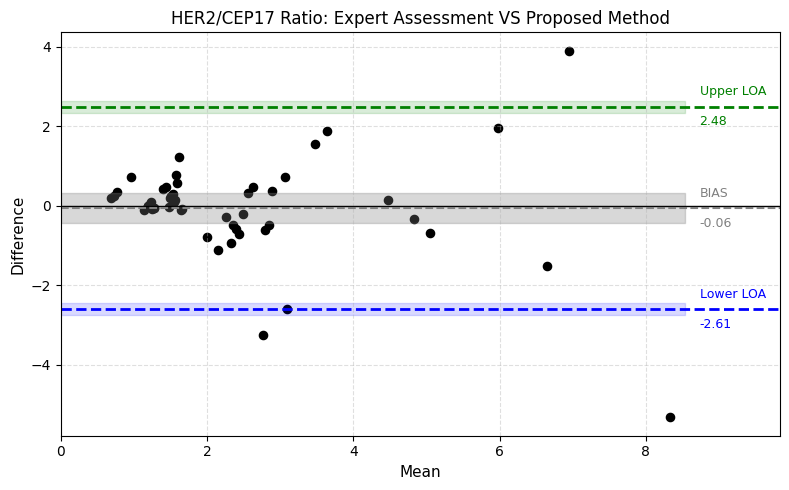

In [26]:
import matplotlib.pyplot as plt
import numpy as np

x_data_max = max(means)
x_plot_max = x_data_max + 1.5  
label_x = x_data_max + 0.4   

plt.figure(figsize=(8, 5))
plt.scatter(means, diffs, color='black', s=35)

plt.axhline(0, color='black', linewidth=1)
plt.axhline(bias, color='gray', linestyle='--', linewidth=1.5)
plt.axhline(loa_high, color='green', linestyle='--', linewidth=2)
plt.axhline(loa_low, color='blue', linestyle='--', linewidth=2)

plt.fill_betweenx([ci_low, ci_high], 0, x_data_max + 0.2, color='gray', alpha=0.3)
plt.fill_betweenx([loa_high - 0.15, loa_high + 0.15], 0, x_data_max + 0.2, color='green', alpha=0.15)
plt.fill_betweenx([loa_low - 0.15, loa_low + 0.15], 0, x_data_max + 0.2, color='blue', alpha=0.15)

plt.text(label_x, bias, f'BIAS\n\n{bias:.2f}', color='gray',
         va='center', ha='left', fontsize=9)
plt.text(label_x, loa_high, f'Upper LOA\n\n{loa_high:.2f}', color='green',
         va='center', ha='left', fontsize=9)
plt.text(label_x, loa_low, f'Lower LOA\n\n{loa_low:.2f}', color='blue',
         va='center', ha='left', fontsize=9)


plt.xlabel('Mean', fontsize=11)
plt.ylabel('Difference', fontsize=11)
plt.title('HER2/CEP17 Ratio: Expert Assessment VS Proposed Method', fontsize=12)
plt.xlim(0, x_plot_max) 
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()